# Código ejecutado AP3-Grupo A




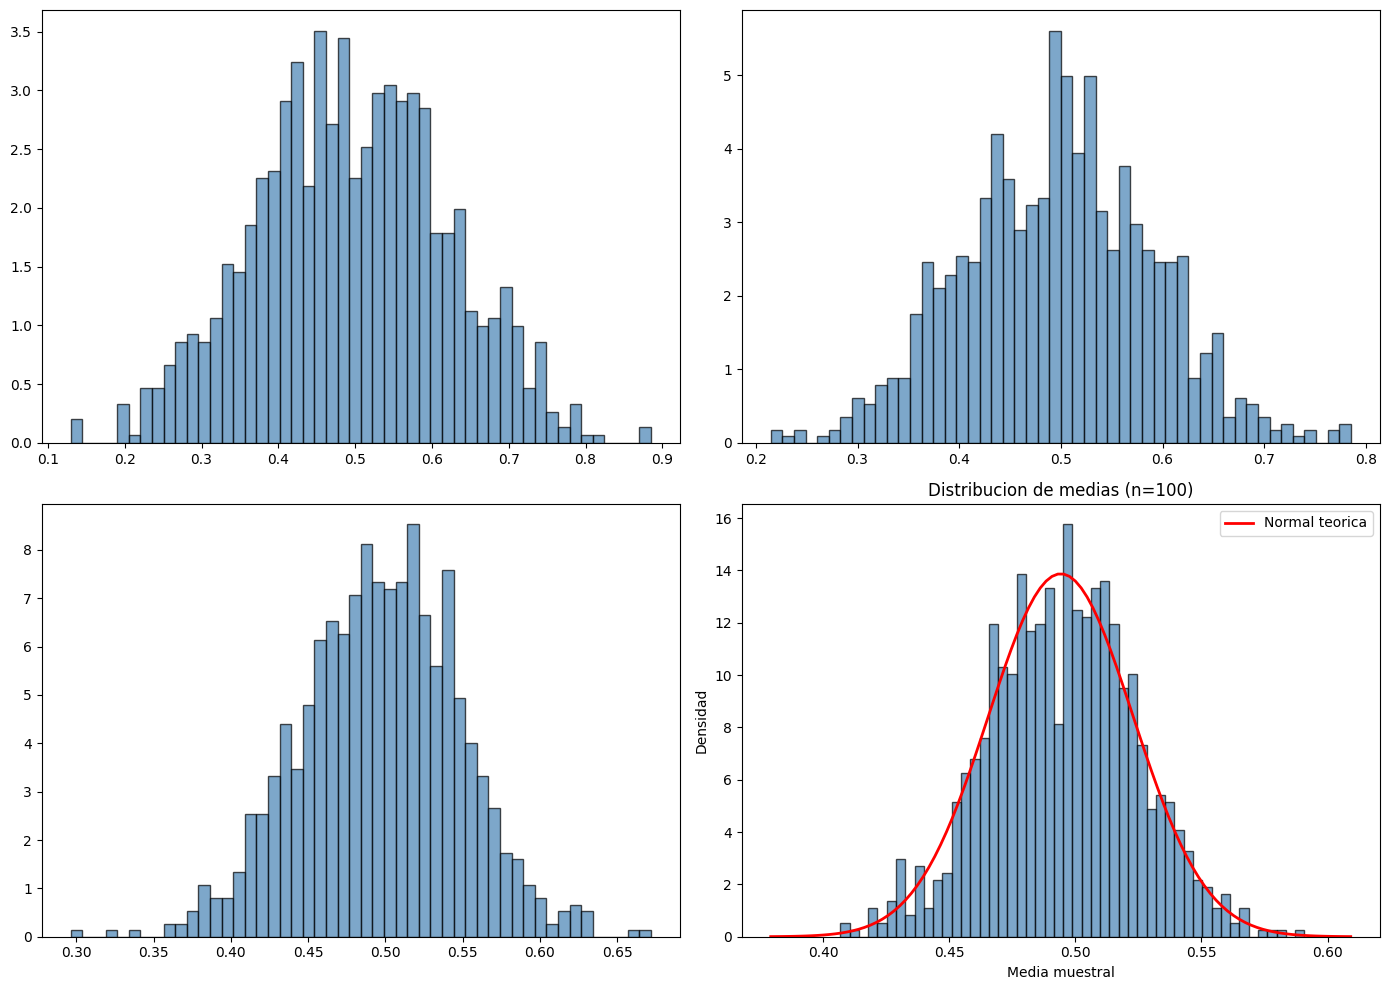

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Fijar semilla para reproducibilidad
np.random.seed(42)

 # Tamano de muestra
n_samples = 10000

# Generar muestras de diferentes distribuciones
uniform_samples = np.random.uniform(0, 1, n_samples)

exponential_samples = np.random.exponential(2, n_samples)
binomial_samples = np.random.binomial(20, 0.3, n_samples)


#1.Calcular medias muestrales para diferentes tamaños de muestra:

# Funcion para calcular medias muestrales
def sample_means(population, sample_sizes, n_samples=1000):
  means = []
  for _ in range(n_samples):
    sample = np.random.choice(population, size=sample_sizes)
    means.append(np.mean(sample))
  return np.array(means)

# Calcular medias para diferentes tamanos de muestra
sample_sizes = [5, 10, 30, 100]
uniform_means = {n: sample_means(uniform_samples, n) for n in sample_sizes}


#2.Visualizar la convergencia hacia la normal:

# Visualizar distribucion de medias muestrales

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
  axes[i].hist(uniform_means[n], bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")

# Superponer curva normal teorica
mu = np.mean(uniform_samples)
sigma = np.std(uniform_samples)
x = np.linspace(mu - 4*sigma/np.sqrt(n), mu + 4*sigma/np.sqrt(n), 100)
normal_pdf = stats.norm.pdf(x, mu, sigma/np.sqrt(n))
axes[i].plot(x, normal_pdf, "r-", linewidth=2, label="Normal teorica")
axes[i].set_title(f"Distribucion de medias (n={n})")
axes[i].set_xlabel("Media muestral")
axes[i].set_ylabel("Densidad")
axes[i].legend()
plt.tight_layout()
plt.show()

Valor critico t (95%, gl=24): 2.0639
Error estandar: 2.0000

Intervalo de confianza del 95%:
[80.87, 89.13] minutos
Valor critico z (95%): 1.9600
Intervalo con z: [81.08, 88.92] minutos

Diferencia en amplitud:
Con t: 8.26 minutos
Con z: 7.84 minutos


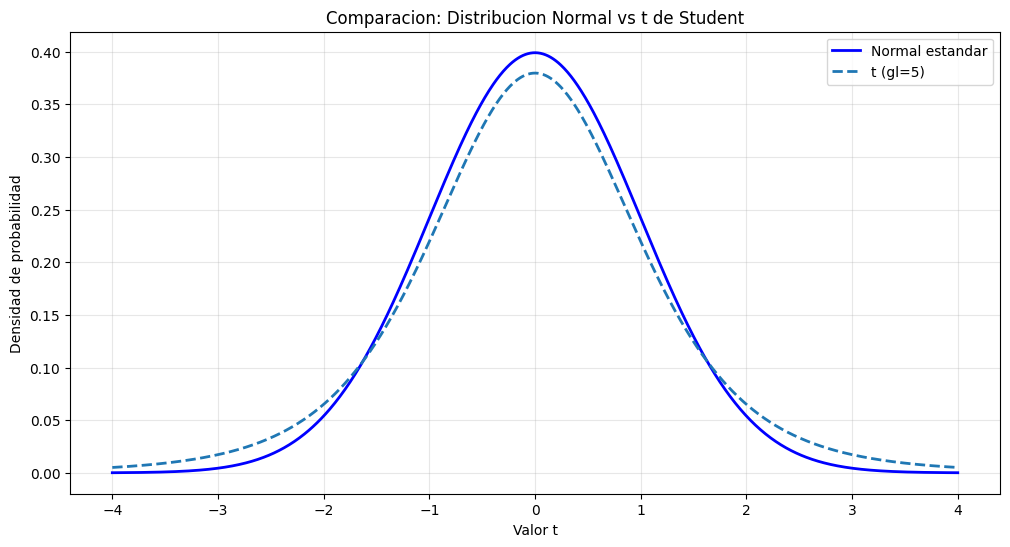

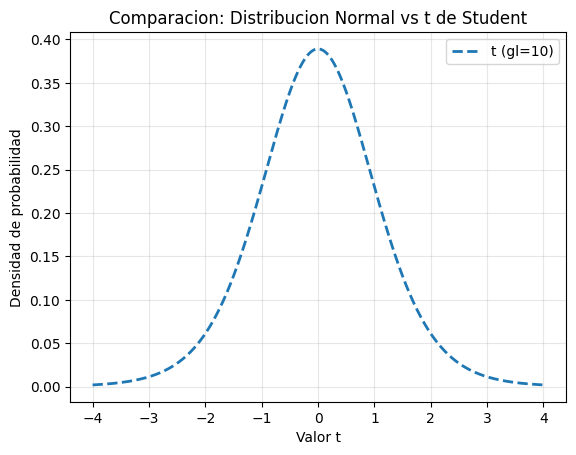

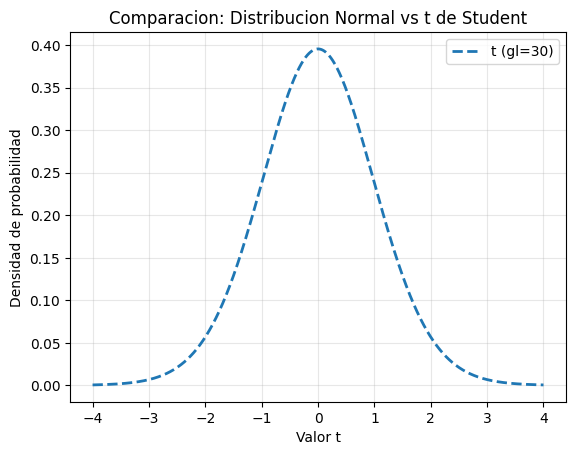

In [ ]:
#3. Definir los parámetros y calcular el intervalo de confianza:

# Parametros del problema
n = 25  # tamano de muestra
x_bar = 85  # media muestral
s = 10  # desviacion estandar muestral
confianza = 0.95
alpha = 1 - confianza

# Grados de libertad
gl = n - 1

# Valor critico t
t_critico = stats.t.ppf(1 - alpha/2, gl)
print(f"Valor critico t (95%, gl={gl}): {t_critico:.4f}")
 # Error estandar
error_estandar = s / np.sqrt(n)
print(f"Error estandar: {error_estandar:.4f}")

# Intervalo de confianza
limite_inferior = x_bar - t_critico * error_estandar
limite_superior = x_bar + t_critico * error_estandar
print(f"\nIntervalo de confianza del 95%:")
print(f"[{limite_inferior:.2f}, {limite_superior:.2f}] minutos")

#4. Comparar con la distribucion normal (z):

# Valor critico z (distribucion normal)

z_critico = stats.norm.ppf(1 - alpha/2)
print(f"Valor critico z (95%): {z_critico:.4f}")

# Intervalo usando z
li_z = x_bar - z_critico * error_estandar
ls_z = x_bar + z_critico * error_estandar
print(f"Intervalo con z: [{li_z:.2f}, {ls_z:.2f}] minutos")

# Comparacion
print(f"\nDiferencia en amplitud:")
print(f"Con t: {limite_superior - limite_inferior:.2f} minutos")
print(f"Con z: {ls_z - li_z:.2f} minutos")


#5. Visualizar la distribución t vs normal:

# Comparar distribuciones t y normal
x = np.linspace(-4, 4, 1000)
plt.figure(figsize=(12, 6))
# Distribucion normal
plt.plot(x, stats.norm.pdf(x), "b-", linewidth=2, label="Normal estandar")

# Distribuciones t con diferentes grados de libertad
for gl in [5, 10, 30]:
  plt.plot(x, stats.t.pdf(x, gl), "--", linewidth=2, label=f"t (gl={gl})")

  plt.xlabel("Valor t")
  plt.ylabel("Densidad de probabilidad")
  plt.title("Comparacion: Distribucion Normal vs t de Student")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()

In [ ]:
#6. 	Calcular el intervalo de confianza para la varianza:

# Parametros
n = 25
s2 = 100 # varianza muestral (s^2 = 10^2)
gl = n - 1

# Valores criticos chi-cuadrado
chi2_inf = stats.chi2.ppf(alpha/2, gl)
chi2_sup = stats.chi2.ppf(1 - alpha/2, gl)
print(f"Valor chi^2 inferior (alpha/2={alpha/2}, gl={gl}): {chi2_inf:.4f}")
print(f"Valor chi^2 superior (1-alpha/2={1-alpha/2}, gl={gl}):{chi2_sup:.4f}")

# Intervalo de confianza para la varianza
li_varianza = (gl * s2) / chi2_sup
ls_varianza = (gl * s2) / chi2_inf

print(f"\nIntervalo de confianza del 95% para la varianza:")
print(f"[{li_varianza:.2f}, {ls_varianza:.2f}]")

# Intervalo para la desviacion estandar

print(f"\nIntervalo de confianza del 95% para la desviacion estandar:")
print(f"[{np.sqrt(li_varianza):.2f}, {np.sqrt(ls_varianza):.2f}]")


Valor chi^2 inferior (alpha/2=0.025000000000000022, gl=24): 12.4012
Valor chi^2 superior (1-alpha/2=0.975, gl=24):39.3641

Intervalo de confianza del 95% para la varianza:
[60.97, 193.53]

Intervalo de confianza del 95% para la desviacion estandar:
[7.81, 13.91]


In [ ]:
#7.     Determinar si el proceso está bajo control (intervalo de confianza del 99%):
# Parametros
n = 40
x_bar = 99.5
s = 2.5
mu_nominal = 100
confianza = 0.99
alpha = 1 - confianza

# Intervalo de confianza del 99%
gl = n - 1
t_critico = stats.t.ppf(1 - alpha/2, gl)
error_estandar = s / np.sqrt(n)

li = x_bar - t_critico * error_estandar
ls = x_bar + t_critico * error_estandar

print(f"Intervalo de confianza del 99%: [{li:.2f}, {ls:.2f}] ohmios")
print(f"Valor nominal: {mu_nominal} ohmios")

if li <= mu_nominal <= ls:
  print("\nConclusion: El proceso ESTA bajo control (el valor nominal esta dentro del IC)")
else:
  print("\nConclusion: El proceso NO esta bajo control (ajuste necesario)")


Intervalo de confianza del 99%: [98.43, 100.57] ohmios
Valor nominal: 100 ohmios

Conclusion: El proceso ESTA bajo control (el valor nominal esta dentro del IC)
